# Interpolation

## Linear, Polynomial, Lagrange & Cubic Splines

Given a set of $n+1$ data points $(x_0, y_0), (x_1, y_1), \ldots, (x_n, y_n)$
with $x_0 < x_1 < \cdots < x_n$, **interpolation** finds a function that passes
**exactly** through every point.

| Method | Construction | Continuity | Behaviour |
|--------|--------------|:----------:|-----------|
| Linear | Straight line per segment | $C^0$ | Robust, low order |
| Polynomial (Vandermonde) | Solve a linear system for coefficients | $C^\infty$ | Can oscillate badly |
| Lagrange | Weighted basis polynomials | $C^\infty$ | Same polynomial as Vandermonde, no LES needed |
| Cubic Spline | Piecewise cubics with smoothness conditions | $C^2$ | Smooth and well-behaved |

Two themes run through this notebook:

1. **A single high-degree polynomial often *overshoots***, especially near the
   ends of the interval (Runge's phenomenon).
2. **Cubic splines stay local**: a wiggle in one region cannot propagate
   across the whole domain.

---


## 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# House-style palette
COLORS = ["#94a3b8", "#64748b", "#7c3aed", "#2563eb", "#ea580c"]


## 2 — Test Functions

We sample data points from known functions so that we can compare any
interpolant to the true underlying curve.

The **Runge function** $f(x) = 1/(1+25x^2)$ is the classic counterexample for
high-degree polynomial interpolation: it is perfectly smooth, yet
equally-spaced polynomial interpolants of degree $\geq 8$ oscillate violently
near the endpoints.

In [2]:
FUNCTIONS = {
    "runge": {
        "label": r"$1/(1+25x^2)$  (Runge)",
        "f": lambda x: 1.0 / (1.0 + 25.0 * x**2),
        "domain": (-1.0, 1.0),
    },
    "smooth": {
        "label": r"$\sin(x) + 0.3\cos(2x)$",
        "f": lambda x: np.sin(x) + 0.3 * np.cos(2 * x),
        "domain": (0.0, 2 * np.pi),
    },
    "wavy": {
        "label": r"$x\,\sin(2x)$",
        "f": lambda x: x * np.sin(2 * x),
        "domain": (0.0, 5.0),
    },
}


def sample(key, n, kind="equal"):
    "Return n equally-spaced or Chebyshev sample points on the domain."
    a, b = FUNCTIONS[key]["domain"]
    f = FUNCTIONS[key]["f"]
    if kind == "equal":
        x = np.linspace(a, b, n)
    elif kind == "chebyshev":
        # Chebyshev nodes mapped from [-1, 1] to [a, b]
        k = np.arange(n)
        cheb = np.cos((2 * k + 1) * np.pi / (2 * n))
        x = 0.5 * (a + b) + 0.5 * (b - a) * cheb
        x = np.sort(x)
    else:
        raise ValueError(kind)
    return x, f(x)


## 3 — Interpolation Methods

### 3.1 Linear Interpolation

For any $x$ in $[x_i, x_{i+1}]$:

$$
y(x) = y_i + \underbrace{\frac{y_{i+1}-y_i}{x_{i+1}-x_i}}_{\text{slope}}\,(x - x_i)
$$

### 3.2 Polynomial Interpolation (Vandermonde)

A polynomial $P(x) = a_0 + a_1 x + a_2 x^2 + \cdots + a_n x^n$ that passes
through $n+1$ points satisfies the linear system

$$
\underbrace{\begin{pmatrix}
1 & x_0 & x_0^2 & \cdots & x_0^n \\
1 & x_1 & x_1^2 & \cdots & x_1^n \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_n & x_n^2 & \cdots & x_n^n
\end{pmatrix}}_{\text{Vandermonde matrix } V}
\begin{pmatrix} a_0 \\ a_1 \\ \vdots \\ a_n \end{pmatrix}
=
\begin{pmatrix} y_0 \\ y_1 \\ \vdots \\ y_n \end{pmatrix}
$$

### 3.3 Lagrange Polynomials

The **same** unique polynomial, written without solving a linear system:

$$
L(x) \;=\; \sum_{i=0}^{n} y_i\, p_i(x)
\qquad\text{with}\qquad
p_i(x) \;=\; \prod_{\substack{j=0 \\ j \neq i}}^{n} \frac{x - x_j}{x_i - x_j}
$$

Each basis polynomial $p_i$ has the property $p_i(x_i)=1$ and $p_i(x_j)=0$ for $j\neq i$.

### 3.4 Cubic Splines

Instead of one global polynomial, fit $n$ cubic pieces $s_i(x)$ on each
sub-interval $[x_i, x_{i+1}]$, with smoothness conditions across nodes
(see Section 7 for the full derivation).

In [3]:
def linear_interp(x_data, y_data, x):
    "Piecewise linear interpolation."
    return np.interp(x, x_data, y_data)


def poly_interp(x_data, y_data):
    "Solve V a = y for polynomial coefficients a_0,...,a_n of P(x) = sum_k a_k x^k."
    n = len(x_data)
    V = np.vander(x_data, n, increasing=True)   # V[i, k] = x_i ** k
    a = np.linalg.solve(V, y_data)
    return a


def poly_eval(coeffs, x):
    "Evaluate P(x) = sum_k coeffs[k] * x**k using Horner method."
    result = np.zeros_like(np.asarray(x, dtype=float))
    for c in reversed(coeffs):
        result = result * x + c
    return result


def lagrange_interp(x_data, y_data, x):
    "Direct evaluation of the Lagrange interpolant at x (array-friendly)."
    x = np.asarray(x, dtype=float)
    n = len(x_data)
    result = np.zeros_like(x)
    for i in range(n):
        Li = np.ones_like(x)
        for j in range(n):
            if j != i:
                Li *= (x - x_data[j]) / (x_data[i] - x_data[j])
        result += y_data[i] * Li
    return result


**Quick sanity check** — Vandermonde and Lagrange must yield the same polynomial.
The maximum difference should be at machine-precision level.

In [4]:
x_data, y_data = sample("smooth", n=6)
x_test = np.linspace(*FUNCTIONS["smooth"]["domain"], 200)

coeffs = poly_interp(x_data, y_data)
y_vandermonde = poly_eval(coeffs, x_test)
y_lagrange = lagrange_interp(x_data, y_data, x_test)

print(f"max |Vandermonde - Lagrange| = {np.max(np.abs(y_vandermonde - y_lagrange)):.2e}")


max |Vandermonde - Lagrange| = 2.51e-14


## 4 — Linear Interpolation

The simplest case: connect adjacent points with straight line segments.
Continuous but not differentiable at the nodes.

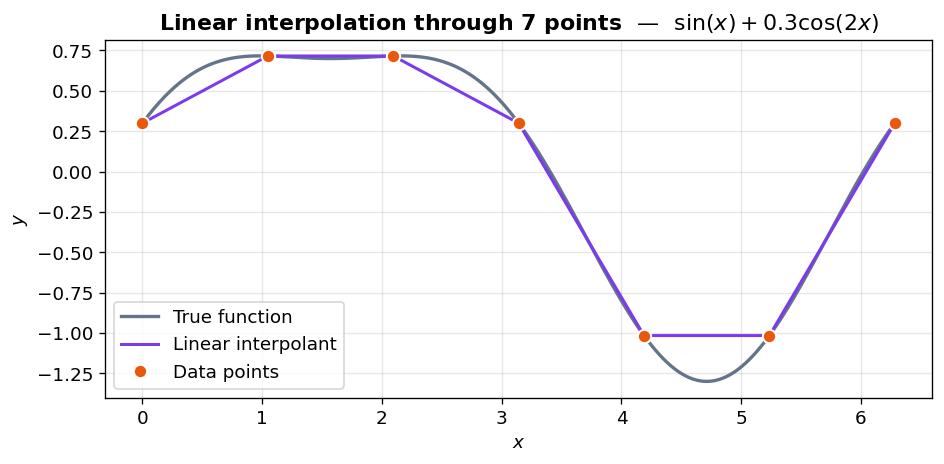

In [5]:
key = "smooth"
f = FUNCTIONS[key]["f"]
a, b = FUNCTIONS[key]["domain"]

x_data, y_data = sample(key, n=7)
x_fine = np.linspace(a, b, 400)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_fine, f(x_fine), color=COLORS[1], lw=2, label="True function", zorder=2)
ax.plot(x_fine, linear_interp(x_data, y_data, x_fine),
        color=COLORS[2], lw=1.8, label="Linear interpolant", zorder=3)
ax.plot(x_data, y_data, "o", color=COLORS[4], markersize=8,
        markeredgecolor="white", markeredgewidth=1.2, label="Data points", zorder=5)

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title(f"Linear interpolation through {len(x_data)} points  —  "
             + FUNCTIONS[key]['label'], fontweight="bold")
ax.legend()
fig.tight_layout()
plt.show()


## 5 — Polynomial Interpolation: The Overshoot Problem

A single polynomial of degree $n$ passes exactly through $n+1$ points. So why
not just keep increasing the degree?

The famous **Runge function** $f(x) = 1/(1+25x^2)$ shows what goes wrong.
Even though $f$ is perfectly smooth, the equally-spaced polynomial interpolant
oscillates more and more violently near the endpoints as we add data points.

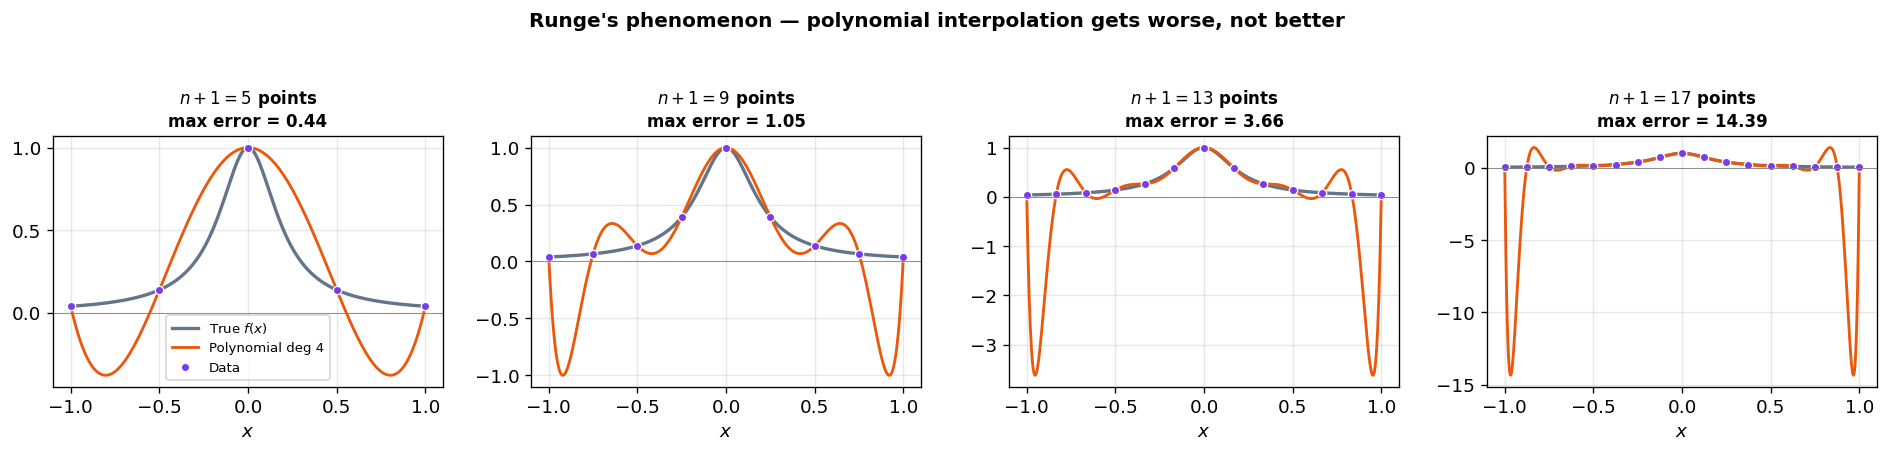

In [6]:
key = "runge"
f = FUNCTIONS[key]["f"]
a, b = FUNCTIONS[key]["domain"]
x_fine = np.linspace(a, b, 600)

degrees = [4, 8, 12, 16]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=False)

for ax, n_pts in zip(axes, [d + 1 for d in degrees]):
    x_data, y_data = sample(key, n=n_pts, kind="equal")
    coeffs = poly_interp(x_data, y_data)
    y_poly = poly_eval(coeffs, x_fine)

    err_max = np.max(np.abs(y_poly - f(x_fine)))

    ax.plot(x_fine, f(x_fine), color=COLORS[1], lw=2, label="True $f(x)$")
    ax.plot(x_fine, y_poly, color=COLORS[4], lw=1.7,
            label=f"Polynomial deg {n_pts - 1}")
    ax.plot(x_data, y_data, "o", color=COLORS[2], markersize=5,
            markeredgecolor="white", markeredgewidth=0.8, label="Data")

    ax.set_title(f"$n+1 = {n_pts}$ points\nmax error = {err_max:.2f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("$x$")
    ax.axhline(0, color="grey", lw=0.5)

axes[0].legend(fontsize=8, loc="lower center")
fig.suptitle("Runge's phenomenon — polynomial interpolation gets worse, not better",
             fontsize=12, fontweight="bold", y=1.04)
fig.tight_layout()
plt.show()


Note how the polynomial interpolant matches the data points exactly (it must!),
but oscillates wildly **between** them near $x = \pm 1$. The error grows as we
add more points.

**Why?** The error of polynomial interpolation contains a factor
$\prod_i (x - x_i)$ which becomes huge near the endpoints when the nodes are
equispaced. Using **Chebyshev nodes** (clustered near the endpoints) cures this:

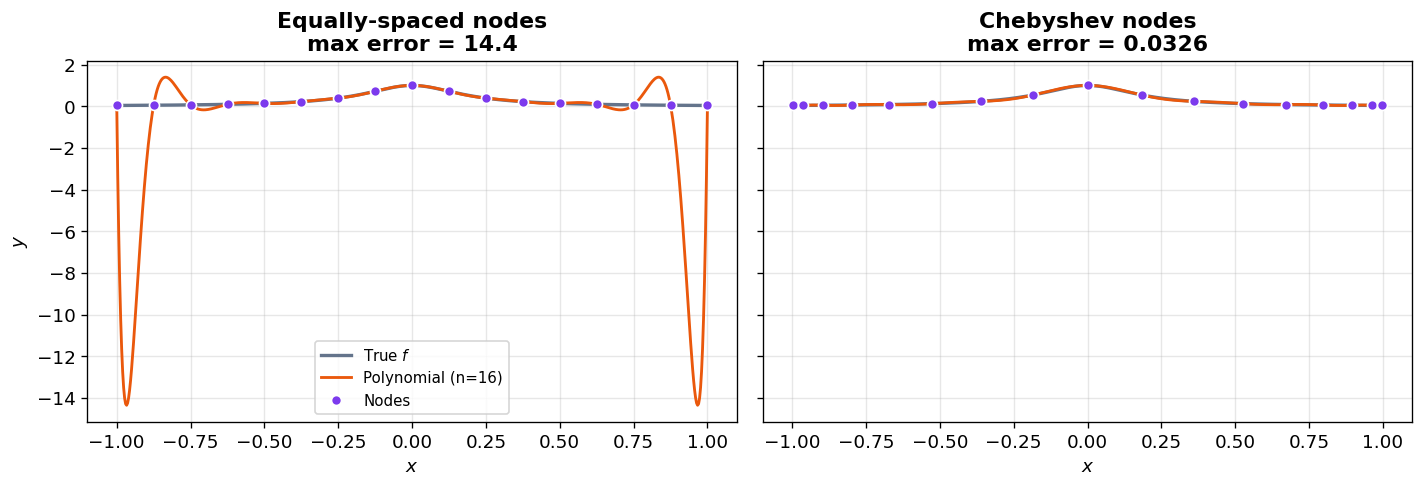

In [7]:
key = "runge"
f = FUNCTIONS[key]["f"]
a, b = FUNCTIONS[key]["domain"]
x_fine = np.linspace(a, b, 600)

n_pts = 17

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

for ax, kind, title in zip(axes, ["equal", "chebyshev"],
                           ["Equally-spaced nodes", "Chebyshev nodes"]):
    x_data, y_data = sample(key, n=n_pts, kind=kind)
    coeffs = poly_interp(x_data, y_data)
    y_poly = poly_eval(coeffs, x_fine)
    err = np.max(np.abs(y_poly - f(x_fine)))

    ax.plot(x_fine, f(x_fine), color=COLORS[1], lw=2, label="True $f$")
    ax.plot(x_fine, y_poly, color=COLORS[4], lw=1.7, label=f"Polynomial (n={n_pts-1})")
    ax.plot(x_data, y_data, "o", color=COLORS[2], markersize=6,
            markeredgecolor="white", markeredgewidth=1.0, label="Nodes")
    ax.set_title(f"{title}\nmax error = {err:.3g}", fontweight="bold")
    ax.set_xlabel("$x$")

axes[0].set_ylabel("$y$")
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()


## 6 — Visualising the Lagrange Basis

The Lagrange polynomial $L(x) = \sum_i y_i \, p_i(x)$ is built from $n+1$
basis polynomials $p_i(x)$, each of degree $n$. Each $p_i$ is **1 at its own
node** $x_i$ and **0 at every other node**:

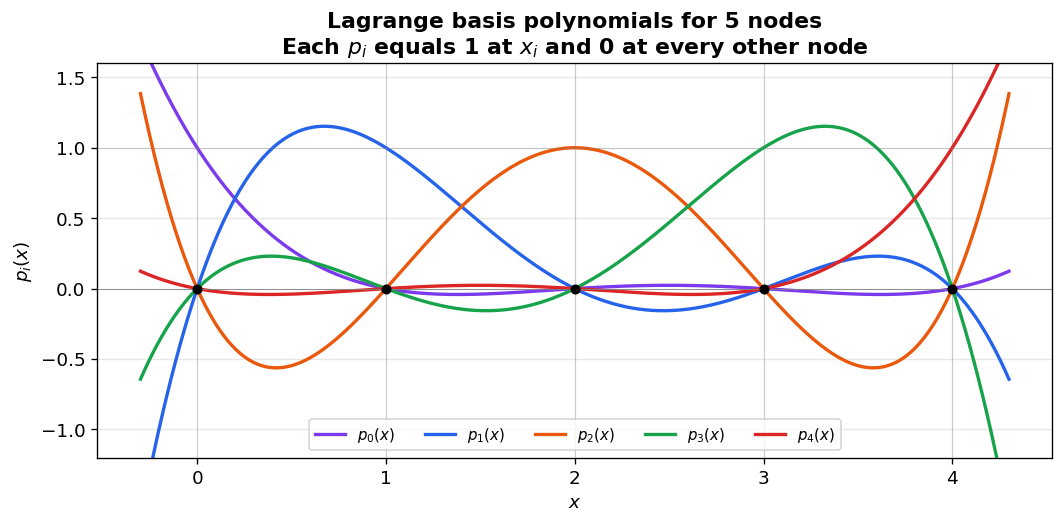

In [8]:
x_data = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
n = len(x_data)
x_fine = np.linspace(-0.3, 4.3, 400)

fig, ax = plt.subplots(figsize=(9, 4.5))

basis_colors = ["#7c3aed", "#2563eb", "#ea580c", "#16a34a", "#dc2626"]

for i in range(n):
    e = np.zeros(n)
    e[i] = 1.0
    p_i = lagrange_interp(x_data, e, x_fine)
    ax.plot(x_fine, p_i, lw=2, color=basis_colors[i], label=f"$p_{i}(x)$")

# Mark nodes
ax.axhline(0, color="grey", lw=0.5)
ax.axhline(1, color="grey", lw=0.5, alpha=0.4)
for xd in x_data:
    ax.axvline(xd, color="grey", lw=0.4, alpha=0.4)
ax.plot(x_data, np.zeros_like(x_data), "o", color="black", markersize=5, zorder=5)

ax.set_xlabel("$x$")
ax.set_ylabel("$p_i(x)$")
ax.set_title("Lagrange basis polynomials for 5 nodes\n"
             "Each $p_i$ equals 1 at $x_i$ and 0 at every other node",
             fontweight="bold")
ax.legend(ncol=5, fontsize=9, loc="lower center")
ax.set_ylim(-1.2, 1.6)
fig.tight_layout()
plt.show()


## 7 — Cubic Spline Construction (Step-by-Step)

For $n$ data points we build $n-1$ cubic pieces. On segment $i$ (between
$x_i$ and $x_{i+1}$) we use the local form

$$
s_i(\xi) \;=\; a_i + b_i\,\xi + c_i\,\xi^2 + d_i\,\xi^3,
\qquad
\xi = x - x_i, \qquad h_i = x_{i+1} - x_i
$$

This gives $4(n-1)$ unknown coefficients. We need exactly that many equations.

| # | Condition | Equation | Count |
|:-:|-----------|----------|:-----:|
| 1 | Pass through left node | $a_i = y_i$ | $n-1$ |
| 2 | Pass through right node | $a_i + b_i h_i + c_i h_i^2 + d_i h_i^3 = y_{i+1}$ | $n-1$ |
| 3 | $C^1$ at interior nodes | $b_i + 2 c_i h_i + 3 d_i h_i^2 = b_{i+1}$ | $n-2$ |
| 4 | $C^2$ at interior nodes | $2 c_i + 6 d_i h_i = 2 c_{i+1}$ | $n-2$ |
| 5 | Natural BCs at the ends | $c_0 = 0$ and $2 c_{n-2} + 6 d_{n-2} h_{n-2} = 0$ | $2$ |

Total: $2(n-1) + 2(n-2) + 2 = 4(n-1)$  ✓

Let's build the linear system **explicitly** for a 4-point example so we can
see and inspect the matrix.

In [9]:
# Small demonstration data set: 4 points -> 3 splines -> 12 unknowns
x_data = np.array([0.0, 1.0, 2.5, 4.0])
y_data = np.array([0.0, 2.0, 1.0, 3.0])

n_pts = len(x_data)
n_seg = n_pts - 1
n_un  = 4 * n_seg              # 12 unknowns
h = np.diff(x_data)            # [h_0, h_1, h_2]

# Unknown ordering:  [a_0, b_0, c_0, d_0,  a_1, b_1, c_1, d_1,  a_2, b_2, c_2, d_2]
# Helper: column index of coefficient k (0=a, 1=b, 2=c, 3=d) of spline i.
def idx(i, k):
    return 4 * i + k

A = np.zeros((n_un, n_un))
rhs = np.zeros(n_un)
row = 0

# (1) s_i(x_i) = y_i  =>  a_i = y_i
for i in range(n_seg):
    A[row, idx(i, 0)] = 1.0
    rhs[row] = y_data[i]
    row += 1

# (2) s_i(x_{i+1}) = y_{i+1}  =>  a_i + b_i h_i + c_i h_i^2 + d_i h_i^3 = y_{i+1}
for i in range(n_seg):
    A[row, idx(i, 0)] = 1.0
    A[row, idx(i, 1)] = h[i]
    A[row, idx(i, 2)] = h[i] ** 2
    A[row, idx(i, 3)] = h[i] ** 3
    rhs[row] = y_data[i + 1]
    row += 1

# (3) C^1 continuity:  b_i + 2 c_i h_i + 3 d_i h_i^2 = b_{i+1}
for i in range(n_seg - 1):
    A[row, idx(i,   1)] =  1.0
    A[row, idx(i,   2)] =  2.0 * h[i]
    A[row, idx(i,   3)] =  3.0 * h[i] ** 2
    A[row, idx(i+1, 1)] = -1.0
    rhs[row] = 0.0
    row += 1

# (4) C^2 continuity:  2 c_i + 6 d_i h_i = 2 c_{i+1}
for i in range(n_seg - 1):
    A[row, idx(i,   2)] =  2.0
    A[row, idx(i,   3)] =  6.0 * h[i]
    A[row, idx(i+1, 2)] = -2.0
    rhs[row] = 0.0
    row += 1

# (5a) Natural BC at left:  c_0 = 0
A[row, idx(0, 2)] = 1.0
rhs[row] = 0.0
row += 1

# (5b) Natural BC at right:  2 c_{n_seg-1} + 6 d_{n_seg-1} h_{n_seg-1} = 0
A[row, idx(n_seg - 1, 2)] = 2.0
A[row, idx(n_seg - 1, 3)] = 6.0 * h[n_seg - 1]
rhs[row] = 0.0
row += 1

print(f"System size: {A.shape[0]} equations  x  {A.shape[1]} unknowns")
print(f"Rows filled: {row}")
print(f"Nonzero entries: {np.count_nonzero(A)}  (out of {A.size})")


System size: 12 equations  x  12 unknowns
Rows filled: 12
Nonzero entries: 32  (out of 144)


Visualise the structure of the assembled matrix and solve:

Spline coefficients (a, b, c, d) per segment:
  s_0(xi) = +0.0000  +2.6847*xi  -0.0000*xi^2  -0.6847*xi^3
  s_1(xi) = +2.0000  +0.6306*xi  -2.0541*xi^2  +0.7928*xi^3
  s_2(xi) = +1.0000  -0.1802*xi  +1.5135*xi^2  -0.3363*xi^3


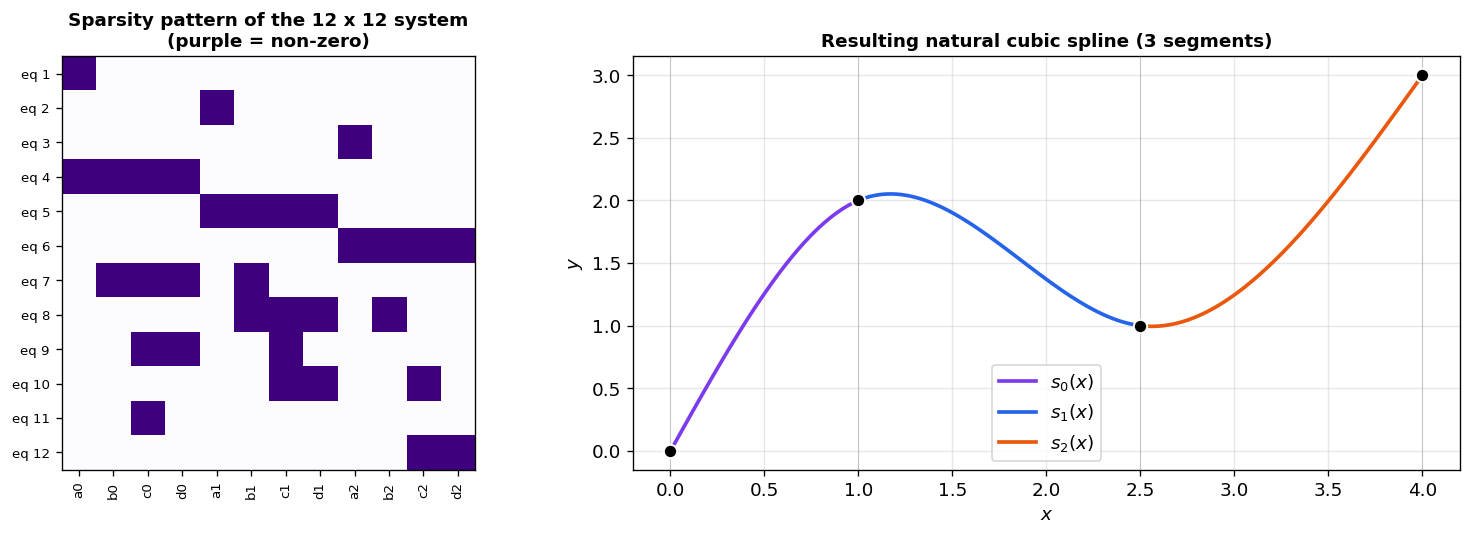

In [10]:
sol = np.linalg.solve(A, rhs)
coeffs = sol.reshape(n_seg, 4)        # rows = segments, columns = a,b,c,d

print("Spline coefficients (a, b, c, d) per segment:")
for i, (a_, b_, c_, d_) in enumerate(coeffs):
    print(f"  s_{i}(xi) = {a_:+.4f}  {b_:+.4f}*xi  {c_:+.4f}*xi^2  {d_:+.4f}*xi^3")

# Visualise the matrix sparsity pattern alongside the resulting spline
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6),
                         gridspec_kw={"width_ratios": [1, 1.4]})

ax = axes[0]
im = ax.imshow(A != 0, cmap="Purples", aspect="equal")
ax.set_title("Sparsity pattern of the 12 x 12 system\n(purple = non-zero)",
             fontweight="bold", fontsize=11)
ax.set_xticks(range(n_un))
ax.set_yticks(range(n_un))
labels = [f"{c}{i}" for i in range(n_seg) for c in ["a", "b", "c", "d"]]
ax.set_xticklabels(labels, fontsize=8, rotation=90)
ax.set_yticklabels([f"eq {r+1}" for r in range(n_un)], fontsize=8)
ax.grid(False)

# Plot the resulting spline
ax = axes[1]
seg_colors = [COLORS[2], COLORS[3], COLORS[4]]
for i in range(n_seg):
    xs = np.linspace(x_data[i], x_data[i + 1], 80)
    xi = xs - x_data[i]
    a_, b_, c_, d_ = coeffs[i]
    ys = a_ + b_ * xi + c_ * xi**2 + d_ * xi**3
    ax.plot(xs, ys, color=seg_colors[i], lw=2.2, label=f"$s_{i}(x)$")

ax.plot(x_data, y_data, "o", color="black", markersize=8,
        markeredgecolor="white", markeredgewidth=1.2, zorder=5)
for xd in x_data:
    ax.axvline(xd, color="grey", lw=0.4, alpha=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Resulting natural cubic spline (3 segments)",
             fontweight="bold", fontsize=11)
ax.legend()

fig.tight_layout()
plt.show()


**Reading the sparsity pattern:** every coefficient $(a_i, b_i, c_i, d_i)$ is
coupled to its neighbours only through the continuity rows (3) and (4). That is
why the matrix has a clear block-banded structure — and why splines are
inexpensive to solve even for thousands of nodes.

## 8 — A General Cubic Spline Function

The construction above generalises directly. Below is a reusable
implementation that returns an evaluator for any number of nodes.

In [11]:
def cubic_spline_natural(x_data, y_data):
    "Build a natural cubic spline; returns (evaluator, coeffs of shape (n_seg, 4))."
    x_data = np.asarray(x_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)
    n_pts = len(x_data)
    n_seg = n_pts - 1
    n_un = 4 * n_seg
    h = np.diff(x_data)

    A = np.zeros((n_un, n_un))
    rhs = np.zeros(n_un)
    row = 0

    def idx(i, k):
        return 4 * i + k

    for i in range(n_seg):                                # (1)
        A[row, idx(i, 0)] = 1.0
        rhs[row] = y_data[i]
        row += 1
    for i in range(n_seg):                                # (2)
        A[row, idx(i, 0)] = 1.0
        A[row, idx(i, 1)] = h[i]
        A[row, idx(i, 2)] = h[i] ** 2
        A[row, idx(i, 3)] = h[i] ** 3
        rhs[row] = y_data[i + 1]
        row += 1
    for i in range(n_seg - 1):                            # (3) C^1
        A[row, idx(i,     1)] =  1.0
        A[row, idx(i,     2)] =  2.0 * h[i]
        A[row, idx(i,     3)] =  3.0 * h[i] ** 2
        A[row, idx(i + 1, 1)] = -1.0
        row += 1
    for i in range(n_seg - 1):                            # (4) C^2
        A[row, idx(i,     2)] =  2.0
        A[row, idx(i,     3)] =  6.0 * h[i]
        A[row, idx(i + 1, 2)] = -2.0
        row += 1
    A[row, idx(0, 2)] = 1.0;                row += 1      # (5a)
    A[row, idx(n_seg - 1, 2)] = 2.0
    A[row, idx(n_seg - 1, 3)] = 6.0 * h[-1]; row += 1     # (5b)

    coeffs = np.linalg.solve(A, rhs).reshape(n_seg, 4)

    def evaluate(x):
        x = np.atleast_1d(np.asarray(x, dtype=float))
        # Find which segment each x belongs to
        i = np.searchsorted(x_data, x, side="right") - 1
        i = np.clip(i, 0, n_seg - 1)
        xi = x - x_data[i]
        a_, b_, c_, d_ = coeffs[i, 0], coeffs[i, 1], coeffs[i, 2], coeffs[i, 3]
        return a_ + b_ * xi + c_ * xi**2 + d_ * xi**3

    return evaluate, coeffs


## 9 — Polynomial vs Spline on the Runge Function

The decisive comparison: take the same equally-spaced nodes and let polynomial
and spline fight it out.

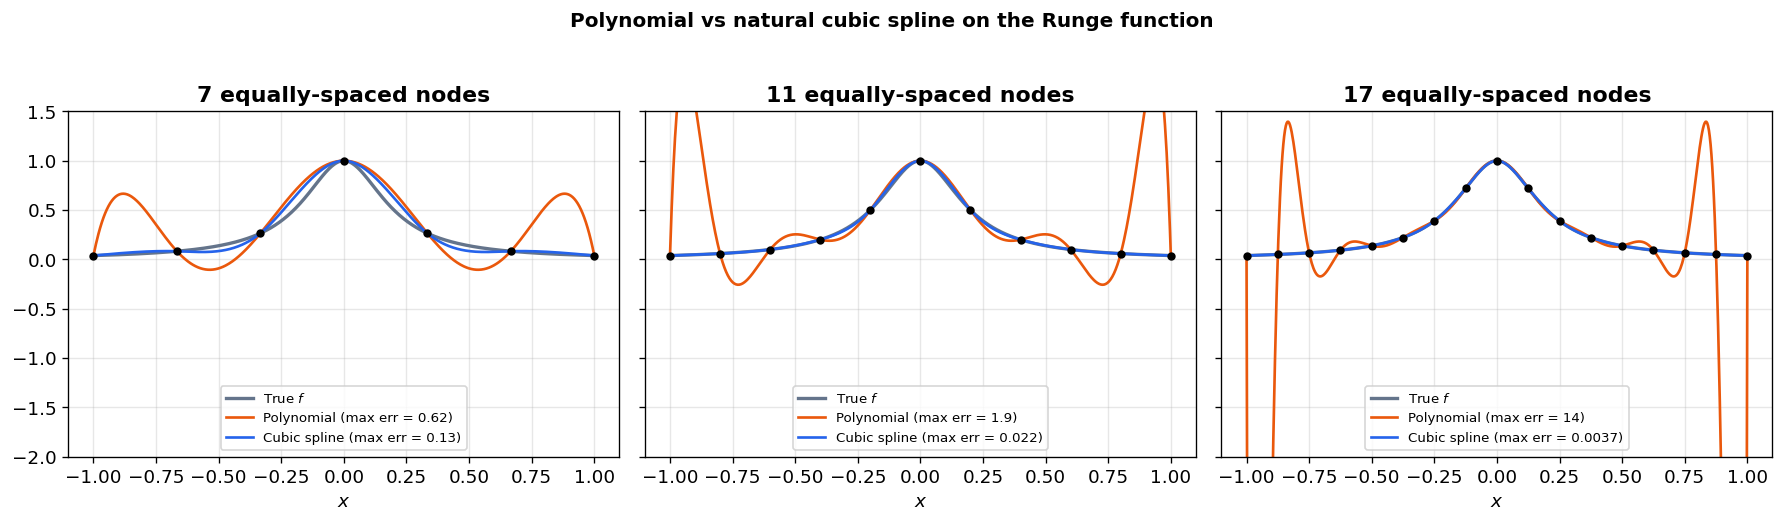

In [12]:
key = "runge"
f = FUNCTIONS[key]["f"]
a, b = FUNCTIONS[key]["domain"]
x_fine = np.linspace(a, b, 600)

n_pts_list = [7, 11, 17]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

for ax, n_pts in zip(axes, n_pts_list):
    x_data, y_data = sample(key, n=n_pts, kind="equal")

    coeffs_poly = poly_interp(x_data, y_data)
    y_poly = poly_eval(coeffs_poly, x_fine)
    err_poly = np.max(np.abs(y_poly - f(x_fine)))

    spline, _ = cubic_spline_natural(x_data, y_data)
    y_spl = spline(x_fine)
    err_spl = np.max(np.abs(y_spl - f(x_fine)))

    ax.plot(x_fine, f(x_fine), color=COLORS[1], lw=2, label="True $f$")
    ax.plot(x_fine, y_poly, color=COLORS[4], lw=1.6,
            label=f"Polynomial (max err = {err_poly:.2g})")
    ax.plot(x_fine, y_spl, color=COLORS[3], lw=1.6,
            label=f"Cubic spline (max err = {err_spl:.2g})")
    ax.plot(x_data, y_data, "o", color="black", markersize=4, zorder=5)

    ax.set_title(f"{n_pts} equally-spaced nodes", fontweight="bold")
    ax.set_xlabel("$x$")
    ax.legend(fontsize=8, loc="lower center")
    ax.set_ylim(-2.0, 1.5)

fig.suptitle("Polynomial vs natural cubic spline on the Runge function",
             fontsize=12, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()


## 10 — Convergence Study

For a well-behaved (smooth) function, both methods converge. For the Runge
function, the polynomial **diverges** while the spline still improves.

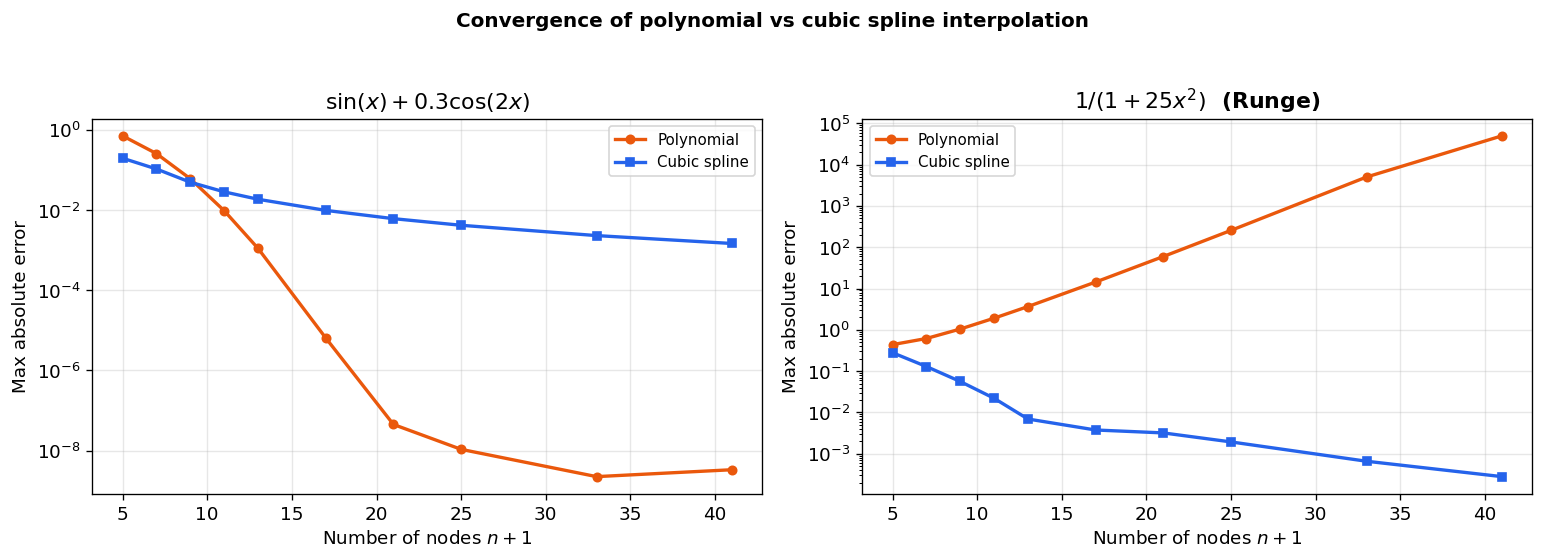

In [13]:
def max_error(true_f, approx, x_fine):
    return np.max(np.abs(approx - true_f(x_fine)))


fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

n_values = np.array([5, 7, 9, 11, 13, 17, 21, 25, 33, 41])

for ax, key in zip(axes, ["smooth", "runge"]):
    f = FUNCTIONS[key]["f"]
    a, b = FUNCTIONS[key]["domain"]
    x_fine = np.linspace(a, b, 800)

    err_poly, err_spl = [], []
    for n_pts in n_values:
        x_data, y_data = sample(key, n=n_pts, kind="equal")
        coeffs_poly = poly_interp(x_data, y_data)
        err_poly.append(max_error(f, poly_eval(coeffs_poly, x_fine), x_fine))
        spline, _ = cubic_spline_natural(x_data, y_data)
        err_spl.append(max_error(f, spline(x_fine), x_fine))

    ax.semilogy(n_values, err_poly, "o-", color=COLORS[4], lw=2,
                markersize=5, label="Polynomial")
    ax.semilogy(n_values, err_spl, "s-", color=COLORS[3], lw=2,
                markersize=5, label="Cubic spline")
    ax.set_title(FUNCTIONS[key]["label"], fontweight="bold")
    ax.set_xlabel("Number of nodes $n+1$")
    ax.set_ylabel("Max absolute error")
    ax.legend(fontsize=9)

fig.suptitle("Convergence of polynomial vs cubic spline interpolation",
             fontsize=12, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()


On the **smooth** function, polynomial interpolation converges fastest because
the function is well-approximated by a single global polynomial. On the
**Runge** function, polynomial interpolation actually gets *worse* as we add
nodes — its maximum error grows without bound. The cubic spline is unfazed
because it stays local.

## 11 — Notes for Students

### Key take-aways

1. **Polynomial interpolation is exact at the nodes**, but on equally-spaced
   nodes it can oscillate dramatically between them. This is **Runge's
   phenomenon** and it is *not* a numerical error — the exact polynomial
   really does behave that way.

2. **Vandermonde and Lagrange give the same polynomial.** The interpolating
   polynomial of degree $n$ through $n+1$ points is *unique*. The two methods
   differ only in *how* they construct it — Vandermonde solves a linear
   system, Lagrange writes it directly as a sum of basis polynomials.

3. **Splines stay local.** A spike in one region of the data cannot send
   waves across the entire domain. This is why splines are the default choice
   for interpolating measured data.

4. **Equally-spaced nodes are usually wrong** for high-degree polynomial
   interpolation. **Chebyshev nodes** (clustered near the endpoints) keep the
   error bounded — but then you may as well use a spline.

5. **Number of equations matters.** A natural cubic spline through $n$ points
   produces a $4(n-1) \times 4(n-1)$ block-banded linear system. Larger
   problems can be reformulated to a tridiagonal system in the second
   derivatives, which is far cheaper to solve.